In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('flights_sample_3m.csv')

In [4]:
df.shape

(3000000, 32)

In [5]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Creamos un csv con solo los datos del 2022 y con las columnas traducidas

In [16]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Filtrar solo el año 2022
df_2022 = df[df['FL_DATE'].dt.year == 2022].copy()

# Traducir nombres de columnas al español
columnas_es = {
    'FL_DATE': 'fecha_vuelo',
    'AIRLINE': 'aerolinea',
    'AIRLINE_DOT': 'aerolinea_dot',
    'AIRLINE_CODE': 'codigo_aerolinea',
    'DOT_CODE': 'codigo_dot',
    'FL_NUMBER': 'numero_vuelo',
    'ORIGIN': 'origen',
    'ORIGIN_CITY': 'ciudad_origen',
    'DEST': 'destino',
    'DEST_CITY': 'ciudad_destino',
    'CRS_DEP_TIME': 'hora_salida_programada',
    'DEP_TIME': 'hora_salida_real',
    'DEP_DELAY': 'retraso_salida',
    'TAXI_OUT': 'tiempo_rodaje_salida',
    'WHEELS_OFF': 'despegue',
    'WHEELS_ON': 'aterrizaje',
    'TAXI_IN': 'tiempo_rodaje_llegada',
    'CRS_ARR_TIME': 'hora_llegada_programada',
    'ARR_TIME': 'hora_llegada_real',
    'ARR_DELAY': 'retraso_llegada',
    'CANCELLED': 'cancelado',
    'CANCELLATION_CODE': 'codigo_cancelacion',
    'DIVERTED': 'desviado',
    'CRS_ELAPSED_TIME': 'duracion_programada',
    'ELAPSED_TIME': 'duracion_real',
    'AIR_TIME': 'tiempo_en_aire',
    'DISTANCE': 'distancia',
    'DELAY_DUE_CARRIER': 'retraso_por_aerolinea',
    'DELAY_DUE_WEATHER': 'retraso_por_clima',
    'DELAY_DUE_NAS': 'retraso_por_trafico_aereo',
    'DELAY_DUE_SECURITY': 'retraso_por_seguridad',
    'DELAY_DUE_LATE_AIRCRAFT': 'retraso_por_avion_tardio'
}

df_2022 = df_2022.rename(columns=columnas_es)

# Verificaciones
print("Tipo de dato de fecha_vuelo:", df_2022['fecha_vuelo'].dtype)
print(f"Filas: {len(df_2022)}")
print(f"Rango de fechas: {df_2022['fecha_vuelo'].min()} a {df_2022['fecha_vuelo'].max()}")
print(f"\nColumnas: {df_2022.columns.tolist()}")

# Guardar el CSV
df_2022.to_csv("flights_2022_es.csv", index=False)
print("\nArchivo guardado: flights_2022_es.csv")

Tipo de dato de fecha_vuelo: datetime64[ns]
Filas: 687860
Rango de fechas: 2022-01-01 00:00:00 a 2022-12-31 00:00:00

Columnas: ['fecha_vuelo', 'aerolinea', 'aerolinea_dot', 'codigo_aerolinea', 'codigo_dot', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_salida_real', 'retraso_salida', 'tiempo_rodaje_salida', 'despegue', 'aterrizaje', 'tiempo_rodaje_llegada', 'hora_llegada_programada', 'hora_llegada_real', 'retraso_llegada', 'cancelado', 'codigo_cancelacion', 'desviado', 'duracion_programada', 'duracion_real', 'tiempo_en_aire', 'distancia', 'retraso_por_aerolinea', 'retraso_por_clima', 'retraso_por_trafico_aereo', 'retraso_por_seguridad', 'retraso_por_avion_tardio']

Archivo guardado: flights_2022_es.csv


In [17]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687860 entries, 1 to 2999997
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   fecha_vuelo                687860 non-null  datetime64[ns]
 1   aerolinea                  687860 non-null  object        
 2   aerolinea_dot              687860 non-null  object        
 3   codigo_aerolinea           687860 non-null  object        
 4   codigo_dot                 687860 non-null  int64         
 5   numero_vuelo               687860 non-null  int64         
 6   origen                     687860 non-null  object        
 7   ciudad_origen              687860 non-null  object        
 8   destino                    687860 non-null  object        
 9   ciudad_destino             687860 non-null  object        
 10  hora_salida_programada     687860 non-null  int64         
 11  hora_salida_real           669844 non-null  float64     

In [18]:
df_2022.nunique()

fecha_vuelo                   365
aerolinea                      17
aerolinea_dot                  17
codigo_aerolinea               17
codigo_dot                     17
numero_vuelo                 6594
origen                        370
ciudad_origen                 364
destino                       370
ciudad_destino                364
hora_salida_programada       1293
hora_salida_real             1431
retraso_salida               1136
tiempo_rodaje_salida          171
despegue                     1432
aterrizaje                   1440
tiempo_rodaje_llegada         167
hora_llegada_programada      1386
hora_llegada_real            1440
retraso_llegada              1167
cancelado                       2
codigo_cancelacion              4
desviado                        2
duracion_programada           566
duracion_real                 660
tiempo_en_aire                632
distancia                    1590
retraso_por_aerolinea         935
retraso_por_clima             451
retraso_por_tr

Agrupamos el dataset por mes.

In [20]:
df_2022 = pd.read_csv("flights_2022_es.csv")
df_2022['fecha_vuelo'] = pd.to_datetime(df_2022['fecha_vuelo'])
df_2022['mes'] = df_2022['fecha_vuelo'].dt.month

print(f"Filas cargadas: {len(df_2022)}")
print('mes' in df_2022.columns)  # debería dar True

Filas cargadas: 687860
True


Nos quedamos con el 25% de registros de cada mes de manera aleatoria. Agregamos un random_state para que nos de siempre la misma muestra de datos. El dataset es muy grande entonces necesitamos reducirlo para que no lleve tanto tiempo correr las APIs y luego quizás el modelo.

In [21]:
df_2022 = df_2022.groupby('mes', group_keys=False).apply(
    lambda x: x.sample(frac=0.25, random_state=42)
)

print(f"Filas después de la muestra: {len(df_2022)}")

Filas después de la muestra: 171966


C:\Users\carro\AppData\Local\Temp\ipykernel_9872\1385801954.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_2022 = df_2022.groupby('mes', group_keys=False).apply(


Filtramos por aeropuertos más importantes.

In [22]:
top_aeropuertos = df_2022['origen'].value_counts()
cobertura = top_aeropuertos.cumsum() / top_aeropuertos.sum()
aeropuertos_relevantes = cobertura[cobertura <= 0.90].index.tolist()

df_2022 = df_2022[df_2022['origen'].isin(aeropuertos_relevantes)]

print(f"Filas después de filtrar aeropuertos: {len(df_2022)}")
print(f"Cantidad de aeropuertos relevantes: {len(aeropuertos_relevantes)}")

Filas después de filtrar aeropuertos: 154586
Cantidad de aeropuertos relevantes: 92


Creamos la variable target para despues predecir

In [23]:
df_2022['retrasado'] = (df_2022['retraso_salida'] > 15).astype(int)

print(df_2022['retrasado'].value_counts())

retrasado
0    123038
1     31548
Name: count, dtype: int64


Hacemos un llamado a una API para obtener la longitud y latitud de cada aeropuerto.

In [24]:
import requests

airports_db = pd.read_csv("https://ourairports.com/data/airports.csv")
airports_db = airports_db[airports_db['iata_code'].isin(aeropuertos_relevantes)]
airports_db = airports_db[['iata_code', 'latitude_deg', 'longitude_deg']].dropna()
airports_db = airports_db.rename(columns={'iata_code': 'origen', 'latitude_deg': 'lat', 'longitude_deg': 'lon'})

print(f"Aeropuertos con coordenadas encontradas: {len(airports_db)}")
airports_db.head()

Aeropuertos con coordenadas encontradas: 92


,origen,lat,lon
38563,ABQ,35.039976,-106.608925
38623,ALB,42.748299,-73.801697
38683,ATL,33.636700,-84.428101
38692,AUS,30.197535,-97.662015
38739,BDL,41.938555,-72.688016


Con esa longitud y latitud que conseguimos, podemos obtener el clima de los registros que pertencen a nuestra dataset, en determinado momento en el aeropuerto de origen.

In [25]:
import time

clima_data = []

for i, row in airports_db.iterrows():
    try:
        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude": row['lat'],
                "longitude": row['lon'],
                "start_date": "2022-01-01",
                "end_date": "2022-12-31",
                "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
                "timezone": "America/New_York"
            },
            timeout=30
        )
        data = response.json()
        temp = pd.DataFrame({
            'fecha_vuelo': data['daily']['time'],
            'temperatura_media': data['daily']['temperature_2m_mean'],
            'precipitacion': data['daily']['precipitation_sum'],
            'viento_max': data['daily']['windspeed_10m_max']
        })
        temp['origen'] = row['origen']
        clima_data.append(temp)
        print(f"OK: {row['origen']} ({i+1}/{len(airports_db)})")
    except Exception as e:
        print(f"Error con {row['origen']}: {e}")
    time.sleep(0.5)

clima_data = pd.concat(clima_data, ignore_index=True)
clima_data['fecha_vuelo'] = pd.to_datetime(clima_data['fecha_vuelo'])

print(f"\nFilas de clima obtenidas: {len(clima_data)}")
clima_data.head()

OK: ABQ (38564/92)
OK: ALB (38624/92)
OK: ATL (38684/92)
OK: AUS (38693/92)
OK: BDL (38740/92)
OK: BHM (38768/92)
OK: BNA (38803/92)
OK: BOI (38808/92)
OK: BOS (38810/92)
OK: BUF (38835/92)
OK: BUR (38837/92)
OK: BWI (38849/92)
OK: CHS (38947/92)
OK: CLE (38968/92)
OK: CLT (38975/92)
OK: CMH (38979/92)
OK: COS (39002/92)
OK: CVG (39043/92)
OK: DAL (39102/92)
OK: DCA (39108/92)
OK: DEN (39117/92)
OK: DFW (39122/92)
OK: DSM (39161/92)
OK: DTW (39168/92)
OK: ELP (39602/92)
OK: EWR (39646/92)
OK: FLL (39744/92)
OK: GEG (39881/92)
OK: GRR (39940/92)
OK: GSP (39944/92)
OK: HOU (40068/92)
OK: HPN (40069/92)
OK: IAD (40161/92)
OK: IAH (40163/92)
OK: IND (40196/92)
OK: JAX (40233/92)
OK: JFK (40241/92)
OK: LAS (40349/92)
OK: LAX (40351/92)
OK: LGA (40376/92)
OK: LGB (40377/92)
OK: MCI (40553/92)
OK: MCO (40556/92)
OK: MDW (40567/92)
OK: MEM (40572/92)
OK: MIA (40598/92)
OK: MKE (40611/92)
OK: MSP (40681/92)
OK: MSY (40684/92)
OK: MYR (40719/92)
OK: OAK (40858/92)
OK: OKC (40885/92)
OK: OMA (409

,fecha_vuelo,temperatura_media,precipitacion,viento_max,origen
0,2022-01-01,2.7,11.7,36.6,ABQ
1,2022-01-02,-4.8,0.0,20.6,ABQ
2,2022-01-03,-2.3,0.0,10.5,ABQ
3,2022-01-04,0.7,0.0,10.4,ABQ
4,2022-01-05,2.6,0.0,12.3,ABQ


Hacemos el merge del clima con el df de 2022.

In [26]:
df_2022 = df_2022.merge(clima_data, on=['origen', 'fecha_vuelo'], how='left')

print(f"Filas después del merge: {len(df_2022)}")
print("Nulos en columnas de clima:")
print(df_2022[['temperatura_media', 'precipitacion', 'viento_max']].isnull().sum())

Filas después del merge: 154586
Nulos en columnas de clima:
temperatura_media    0
precipitacion        0
viento_max           0
dtype: int64


Nos quedamos solo con las columnas que son de antes del hecho generador, para evitar el leakage.

In [27]:
columnas_validas = [
    'fecha_vuelo', 'aerolinea', 'codigo_aerolinea', 'numero_vuelo',
    'origen', 'ciudad_origen', 'destino', 'ciudad_destino',
    'hora_salida_programada', 'hora_llegada_programada',
    'duracion_programada', 'distancia',
    'temperatura_media', 'precipitacion', 'viento_max'
]

df_modelo = df_2022[columnas_validas + ['retrasado']]

print(f"Filas finales en df_modelo: {len(df_modelo)}")
print(df_modelo.columns.tolist())

Filas finales en df_modelo: 154586
['fecha_vuelo', 'aerolinea', 'codigo_aerolinea', 'numero_vuelo', 'origen', 'ciudad_origen', 'destino', 'ciudad_destino', 'hora_salida_programada', 'hora_llegada_programada', 'duracion_programada', 'distancia', 'temperatura_media', 'precipitacion', 'viento_max', 'retrasado']


In [28]:
#Quiero separar en categóricas y numéricas, para poder hacer un análisis más profundo de los datos. 
categorical_columns = df_2022.select_dtypes(include=['object']).columns
numerical_columns = df_2022.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)


Categorical columns: Index(['aerolinea', 'aerolinea_dot', 'codigo_aerolinea', 'origen',
       'ciudad_origen', 'destino', 'ciudad_destino', 'codigo_cancelacion'],
      dtype='object')
Numerical columns: Index(['codigo_dot', 'numero_vuelo', 'hora_salida_programada',
       'hora_salida_real', 'retraso_salida', 'tiempo_rodaje_salida',
       'despegue', 'aterrizaje', 'tiempo_rodaje_llegada',
       'hora_llegada_programada', 'hora_llegada_real', 'retraso_llegada',
       'cancelado', 'desviado', 'duracion_programada', 'duracion_real',
       'tiempo_en_aire', 'distancia', 'retraso_por_aerolinea',
       'retraso_por_clima', 'retraso_por_trafico_aereo',
       'retraso_por_seguridad', 'retraso_por_avion_tardio', 'retrasado',
       'temperatura_media', 'precipitacion', 'viento_max'],
      dtype='object')


Análisis Outliers

In [29]:
for col in numerical_columns:
    Q1 = df_2022[col].quantile(0.25)
    Q3 = df_2022[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_2022[(df_2022[col] < lower_bound) | (df_2022[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(df_2022)) * 100
    print(f"Column: {col}, Outliers: {len(outliers)}", f"({outlier_percentage:.2f}%)")

Column: codigo_dot, Outliers: 0 (0.00%)
Column: numero_vuelo, Outliers: 44 (0.03%)
Column: hora_salida_programada, Outliers: 0 (0.00%)
Column: hora_salida_real, Outliers: 0 (0.00%)
Column: retraso_salida, Outliers: 17805 (11.52%)
Column: tiempo_rodaje_salida, Outliers: 7889 (5.10%)
Column: despegue, Outliers: 0 (0.00%)
Column: aterrizaje, Outliers: 0 (0.00%)
Column: tiempo_rodaje_llegada, Outliers: 9353 (6.05%)
Column: hora_llegada_programada, Outliers: 0 (0.00%)
Column: hora_llegada_real, Outliers: 0 (0.00%)
Column: retraso_llegada, Outliers: 13608 (8.80%)
Column: cancelado, Outliers: 4098 (2.65%)
Column: desviado, Outliers: 336 (0.22%)
Column: duracion_programada, Outliers: 8279 (5.36%)
Column: duracion_real, Outliers: 7386 (4.78%)
Column: tiempo_en_aire, Outliers: 8121 (5.25%)
Column: distancia, Outliers: 9625 (6.23%)
Column: retraso_por_aerolinea, Outliers: 3109 (2.01%)
Column: retraso_por_clima, Outliers: 1596 (1.03%)
Column: retraso_por_trafico_aereo, Outliers: 2366 (1.53%)
Colum

Las columnas con los outliers más significativos son rafaga_viento y restraso salida

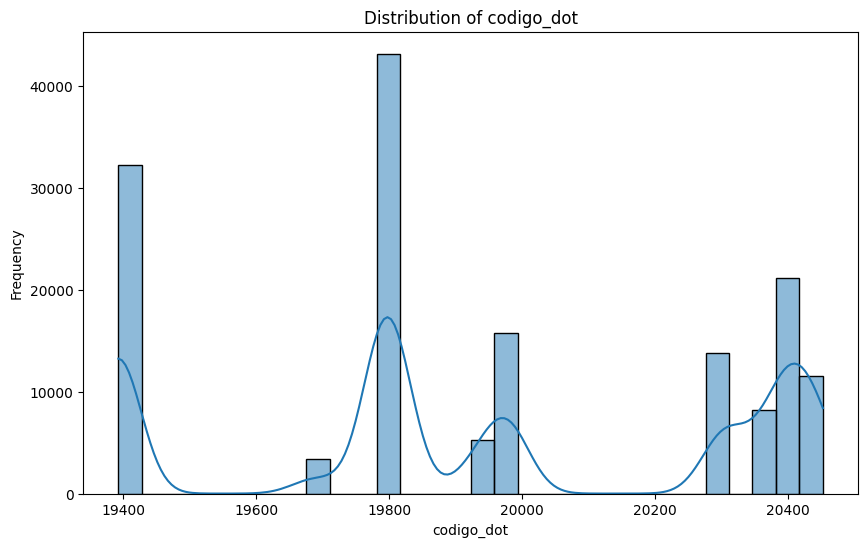

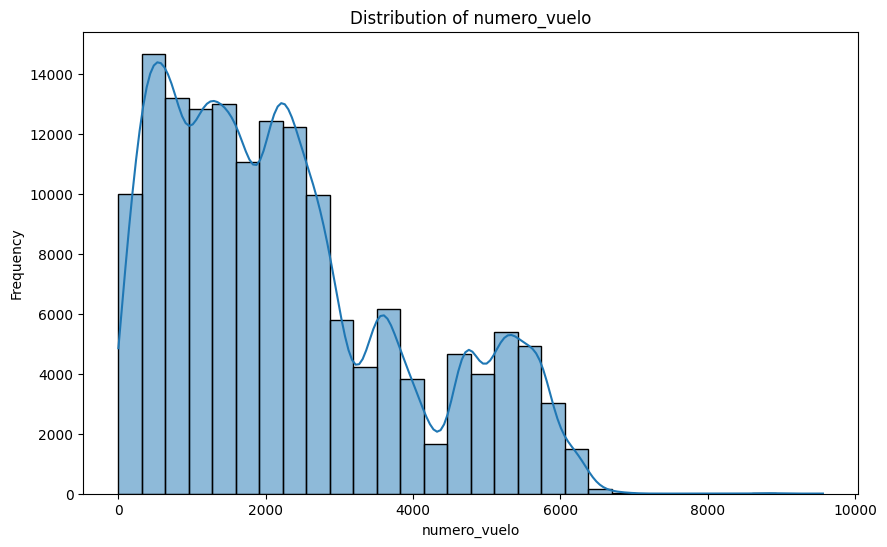

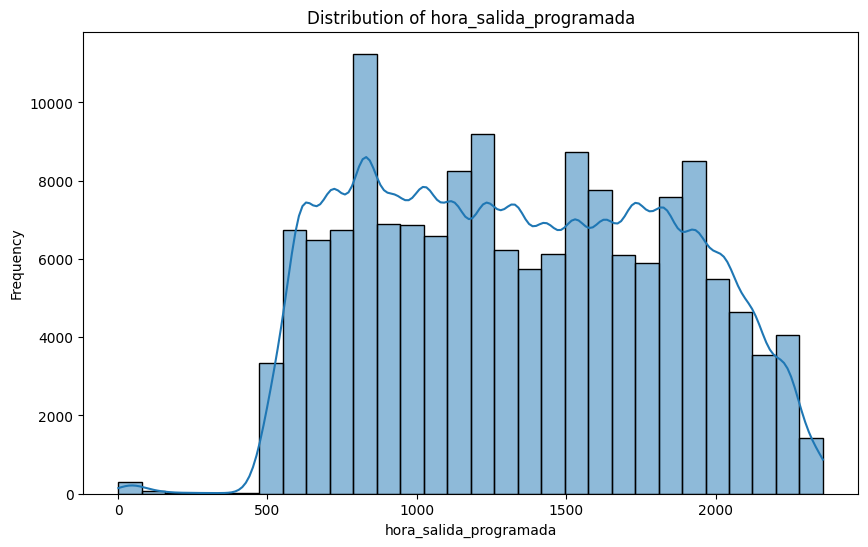

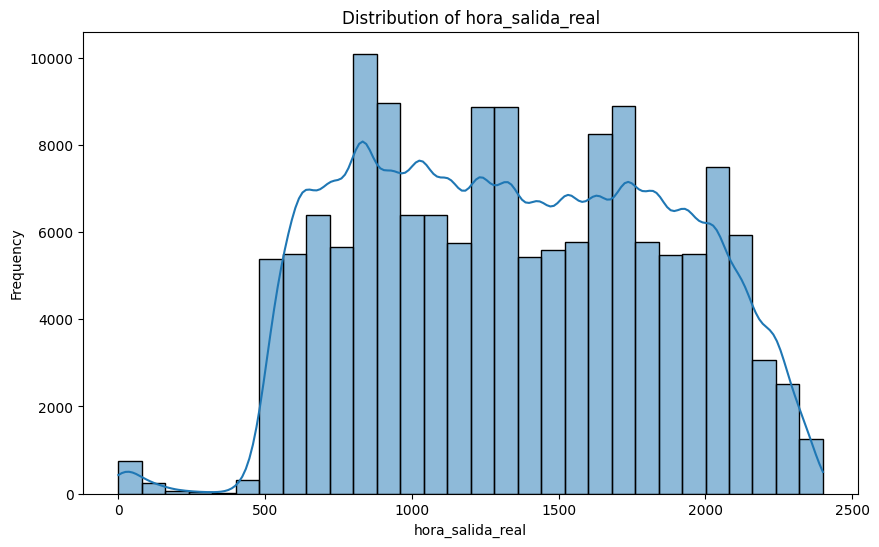

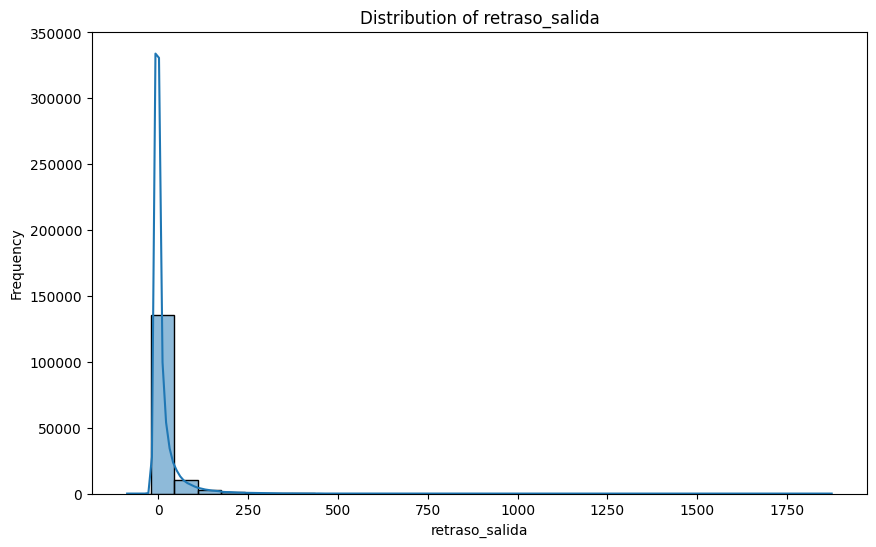

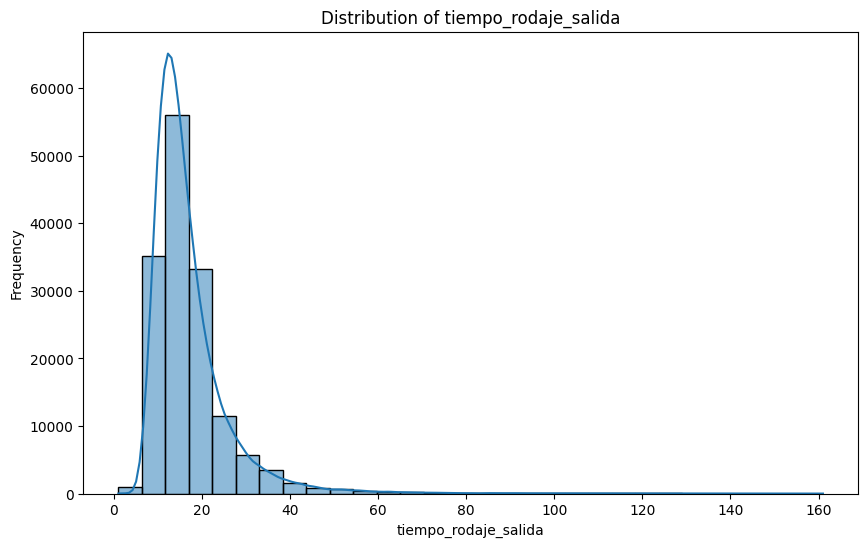

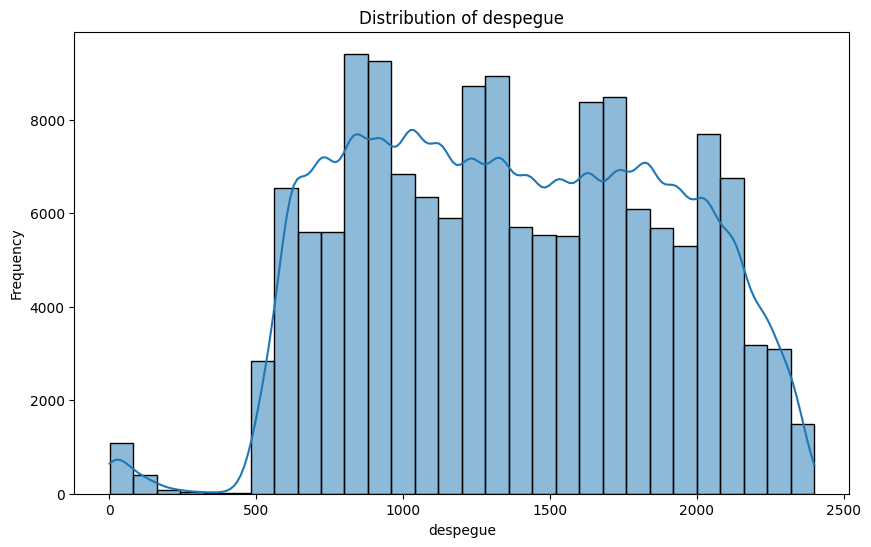

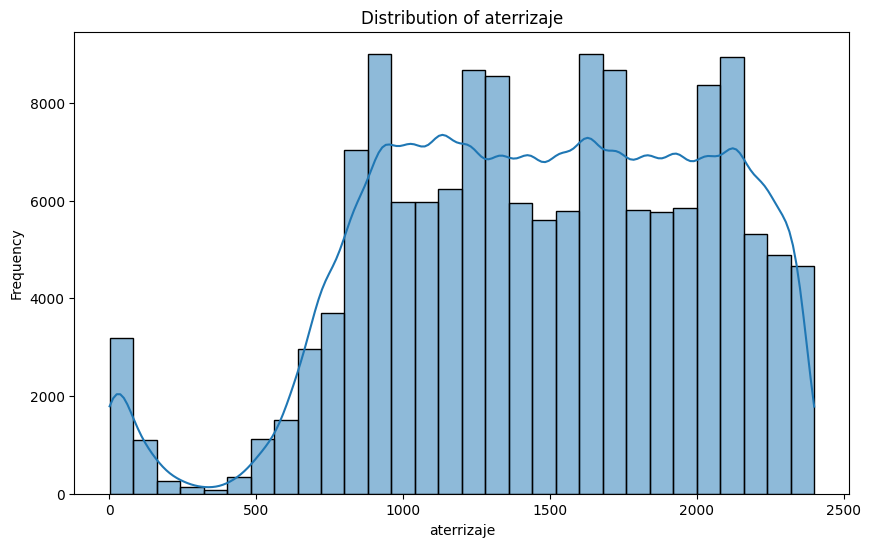

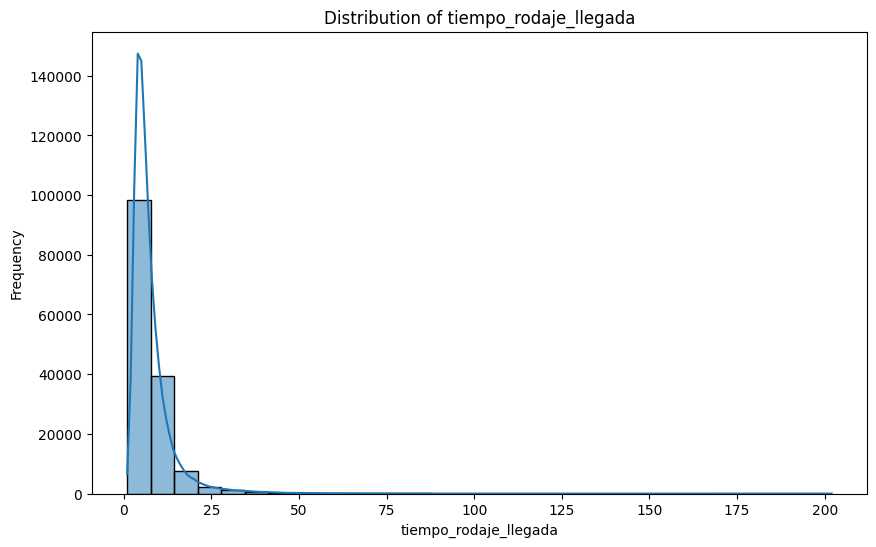

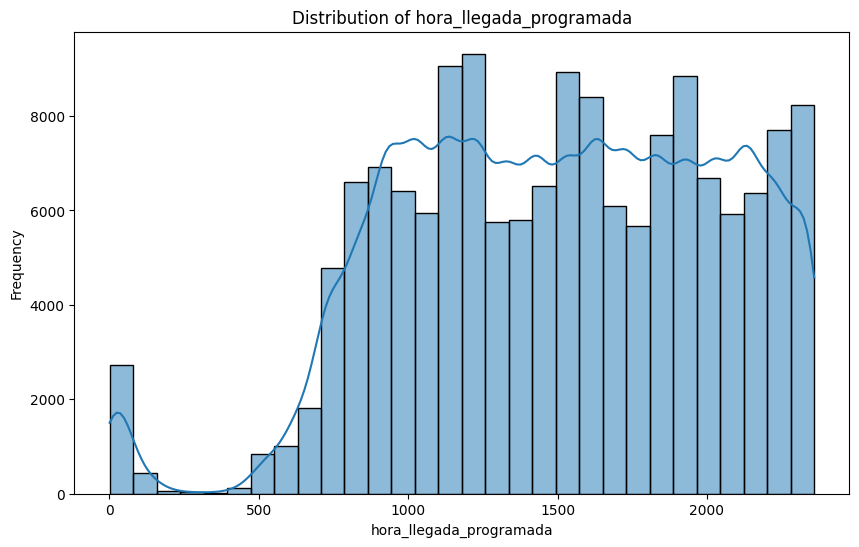

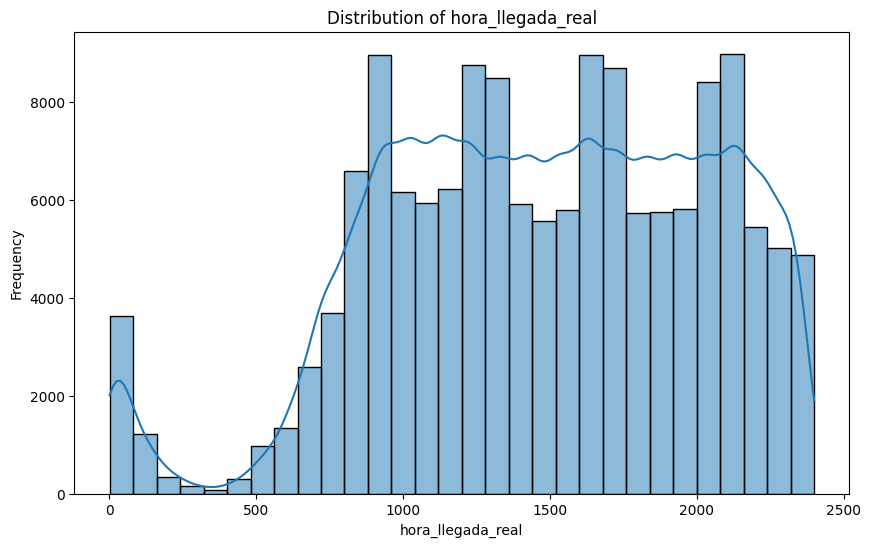

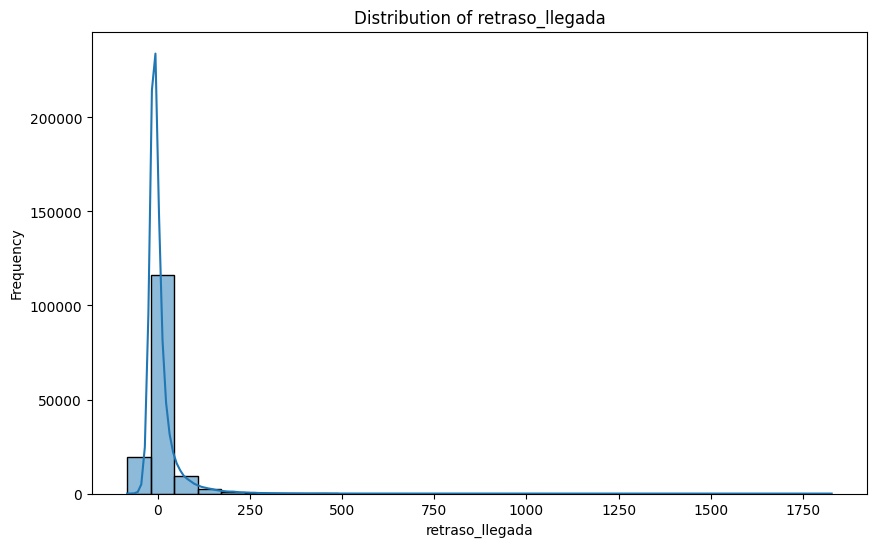

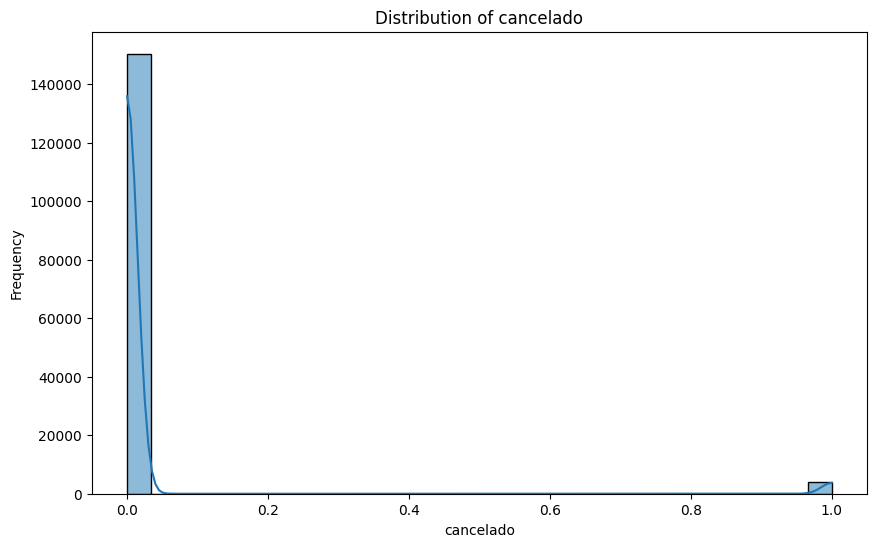

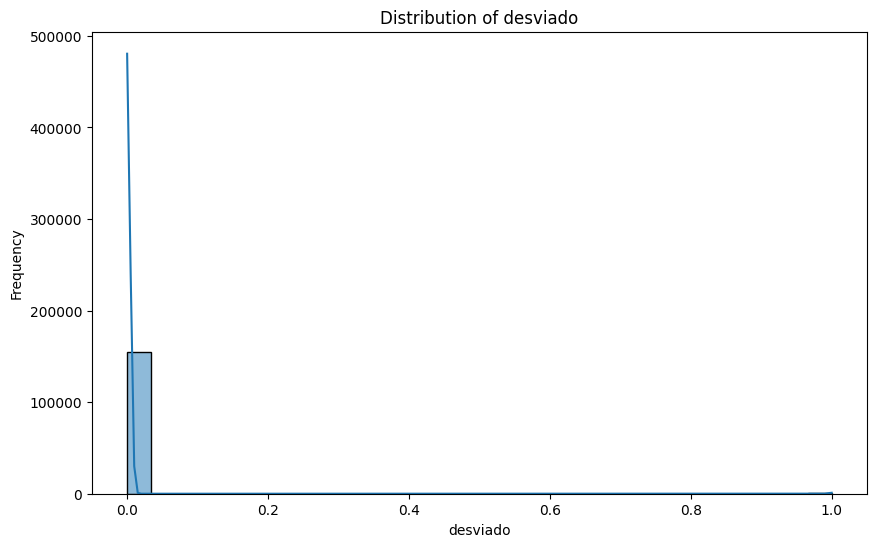

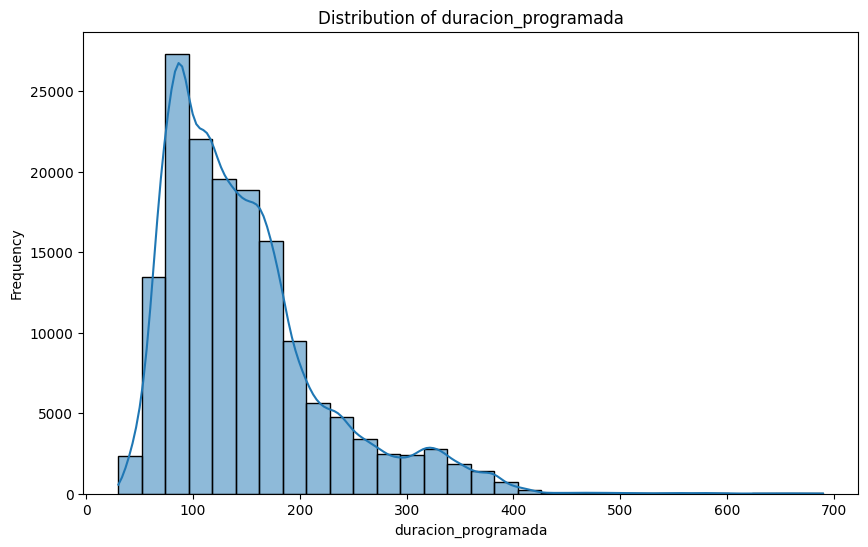

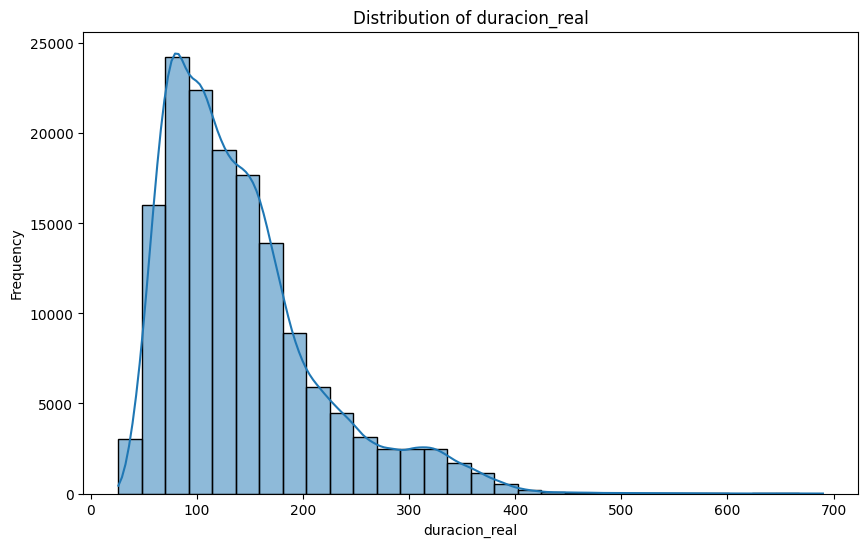

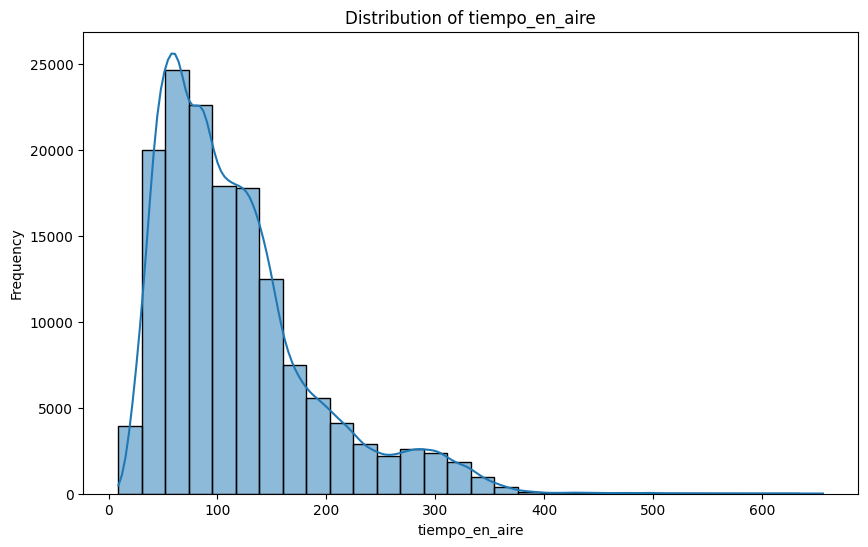

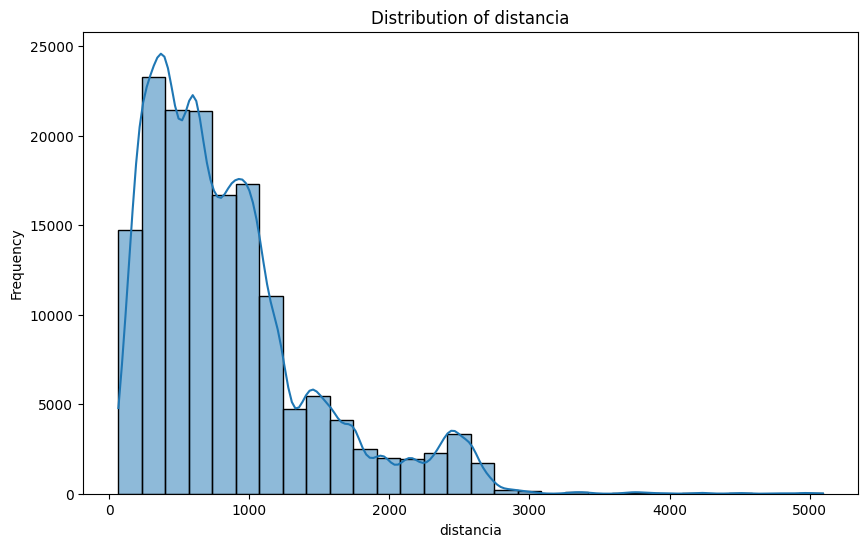

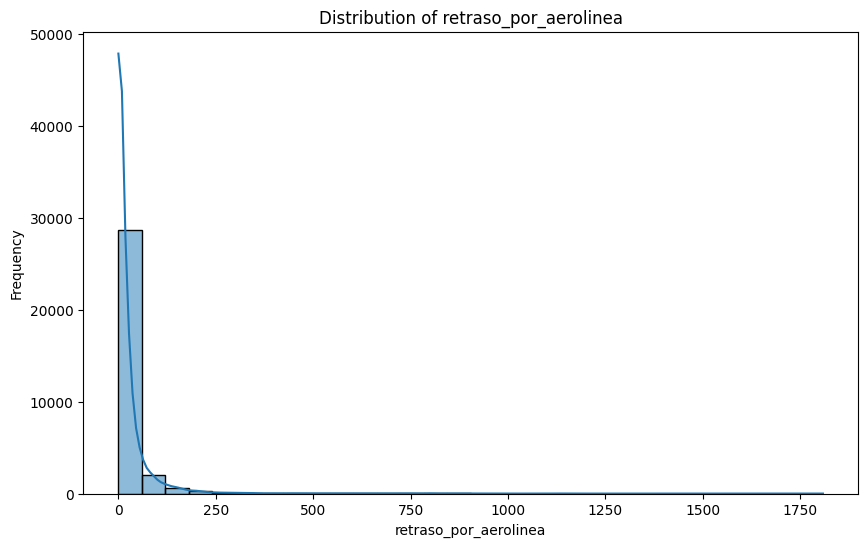

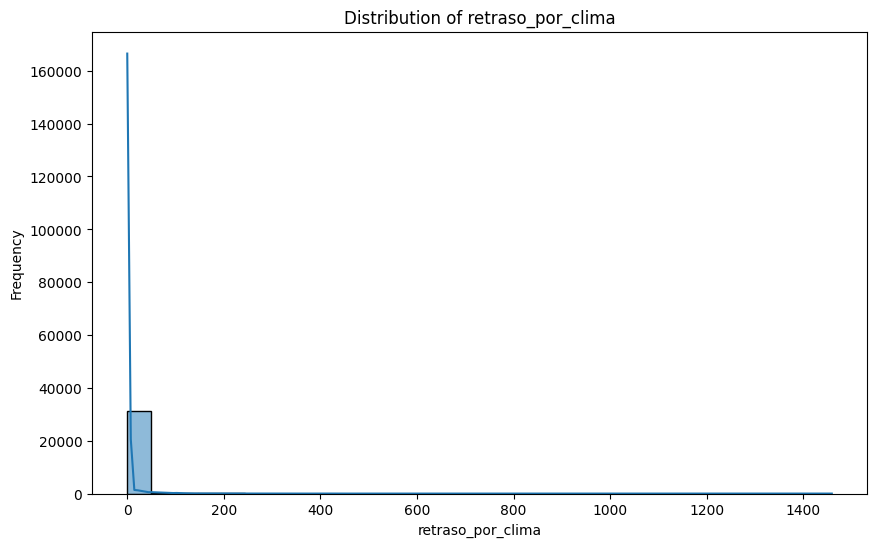

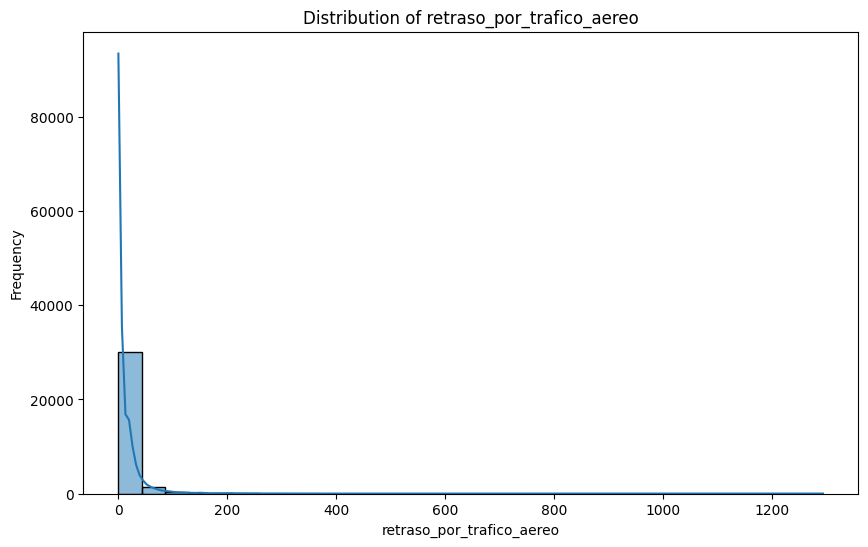

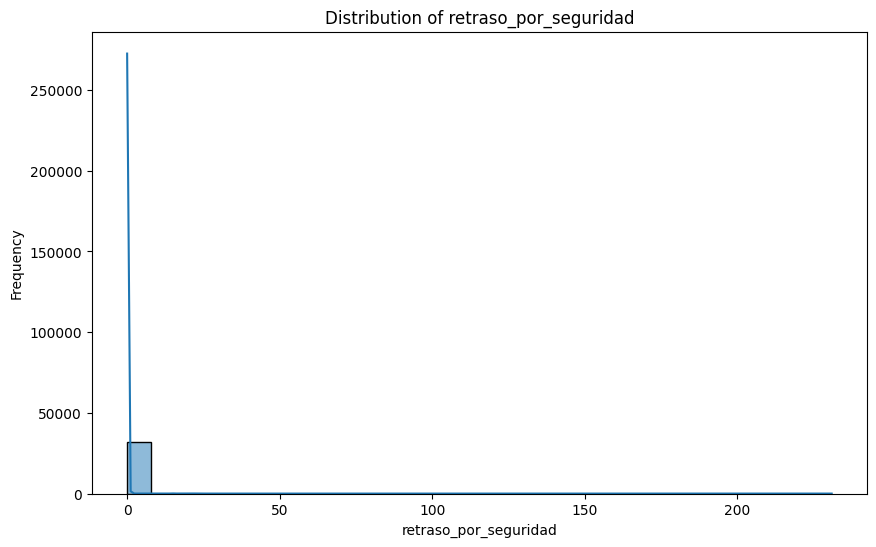

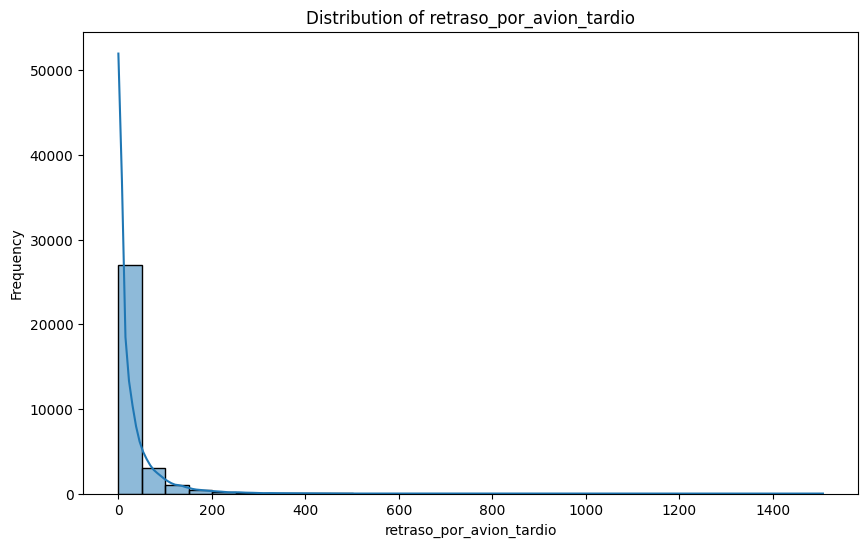

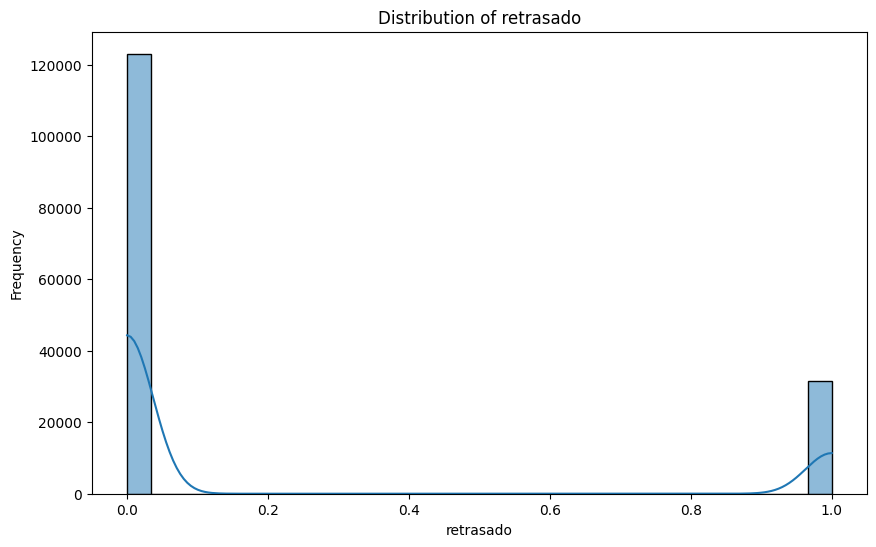

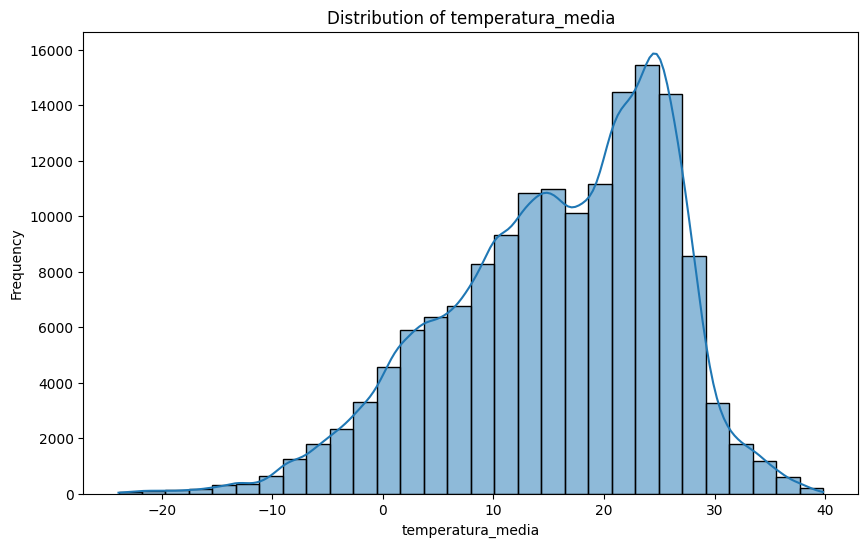

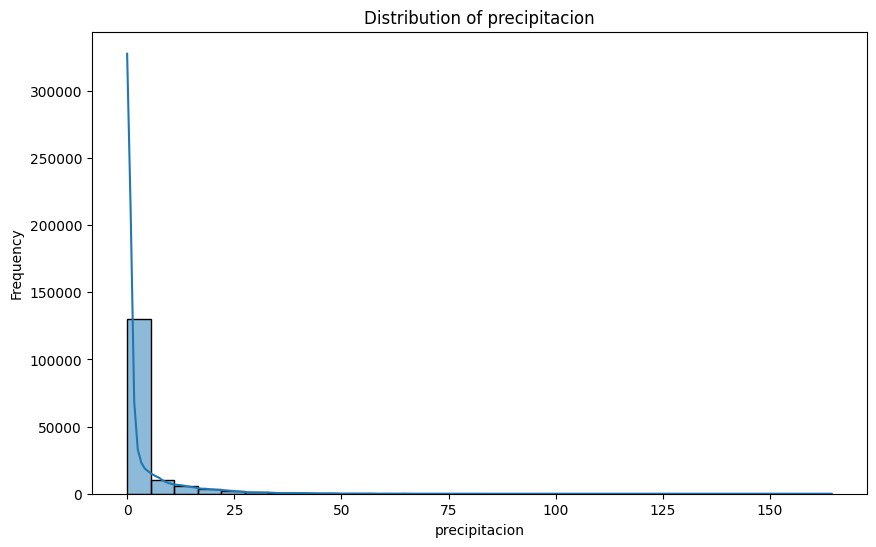

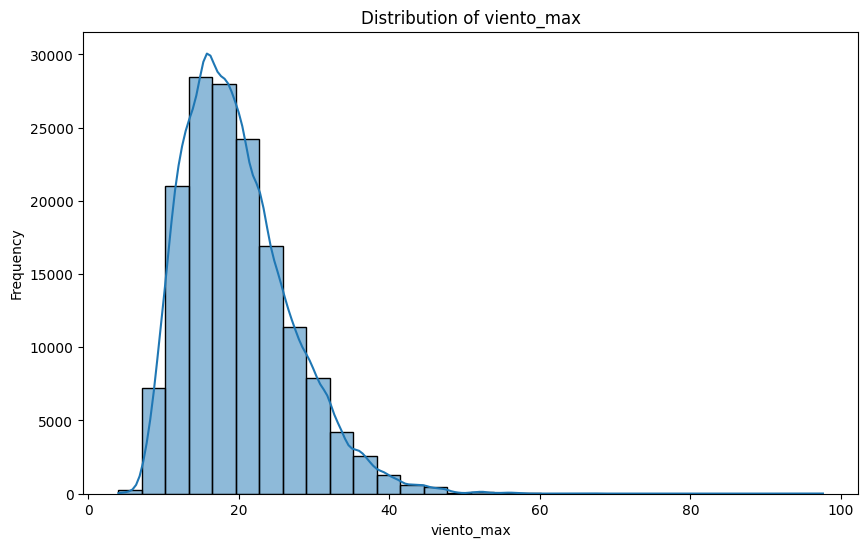

In [30]:
#quiero graficar la distribución de las variables numéricas para ver si hay alguna que tenga una distribución anormal.
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_2022[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Ánalisis Univariado

In [31]:
#Análisis univariado de las variables categóricas
resumen= pd.DataFrame({
    'Media':df_2022[numerical_columns].mean(), 
    'Mediana':df_2022[numerical_columns].median(),
    'Moda':df_2022[numerical_columns].mode().iloc[0],
    'Desviación Estándar':df_2022[numerical_columns].std(),
    'IQR':df_2022[numerical_columns].quantile(0.75) - df_2022[numerical_columns].quantile(0.25),
    'Skewness':df_2022[numerical_columns].skew()}).round(3)
print('Resumen estadístico de las variables numéricas:')
print(resumen)

Resumen estadístico de las variables numéricas:
                               Media  Mediana     Moda  Desviación Estándar  \
codigo_dot                 19940.640  19805.0  19393.0              374.402   
numero_vuelo                2295.423   2002.0    772.0             1635.685   
hora_salida_programada      1344.282   1328.0    600.0              494.489   
hora_salida_real            1347.848   1331.0    555.0              509.665   
retraso_salida                12.645     -1.0     -5.0               51.254   
tiempo_rodaje_salida          17.027     15.0     12.0                9.161   
despegue                    1368.905   1344.0    611.0              512.424   
aterrizaje                  1466.910   1505.0    958.0              544.827   
tiempo_rodaje_llegada          7.741      6.0      4.0                6.623   
hora_llegada_programada     1498.314   1521.0   2359.0              525.940   
hora_llegada_real           1469.253   1508.0   2149.0              550.371   
retr

In [32]:
# Clasificar los vuelos: retrasado (>15 min) vs no retrasado
df_2022['retrasado'] = (df_2022['retraso_salida'] > 15).astype(int)

# Conteo absoluto
conteo = df_2022['retrasado'].value_counts()
print("Conteo de vuelos:")
print(conteo)

# Porcentaje
porcentaje = df_2022['retrasado'].value_counts(normalize=True) * 100
print("\nPorcentaje de vuelos:")
print(porcentaje.round(2))

Conteo de vuelos:
retrasado
0    123038
1     31548
Name: count, dtype: int64

Porcentaje de vuelos:
retrasado
0    79.59
1    20.41
Name: proportion, dtype: float64


Por lo que podemos ver en esta parte del código podríamos decir que existe un desbalanceo de clases ya que el 20% del dataset son vuelos con retrasos y el otro 80% son vuelos que salieron a tiempo. Por lo que, a la hora de entrenar el modelo no deberíamos mirar únicamente el accuracy y además vamos a tener que realizar un balanceo de clases

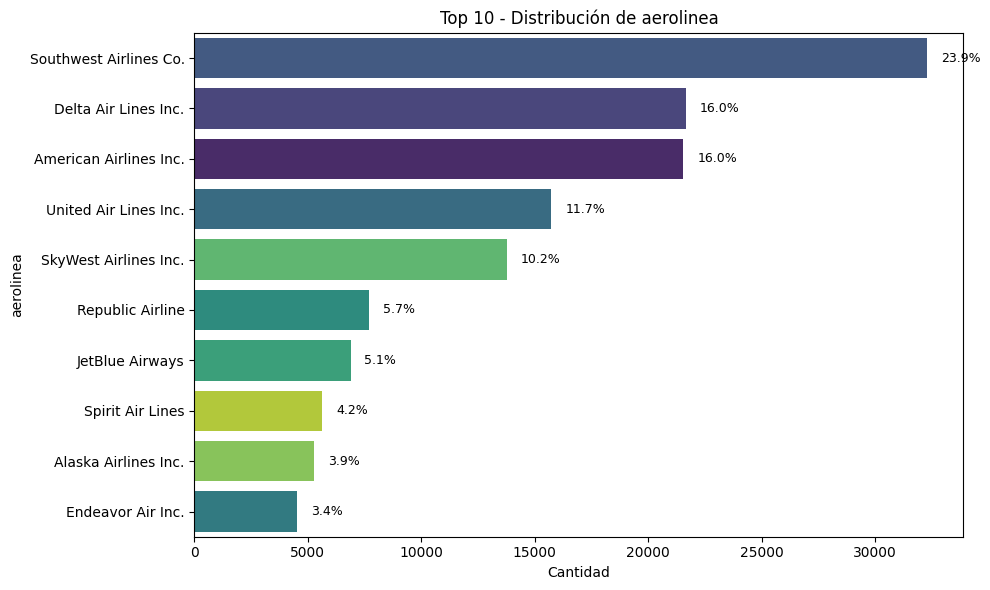

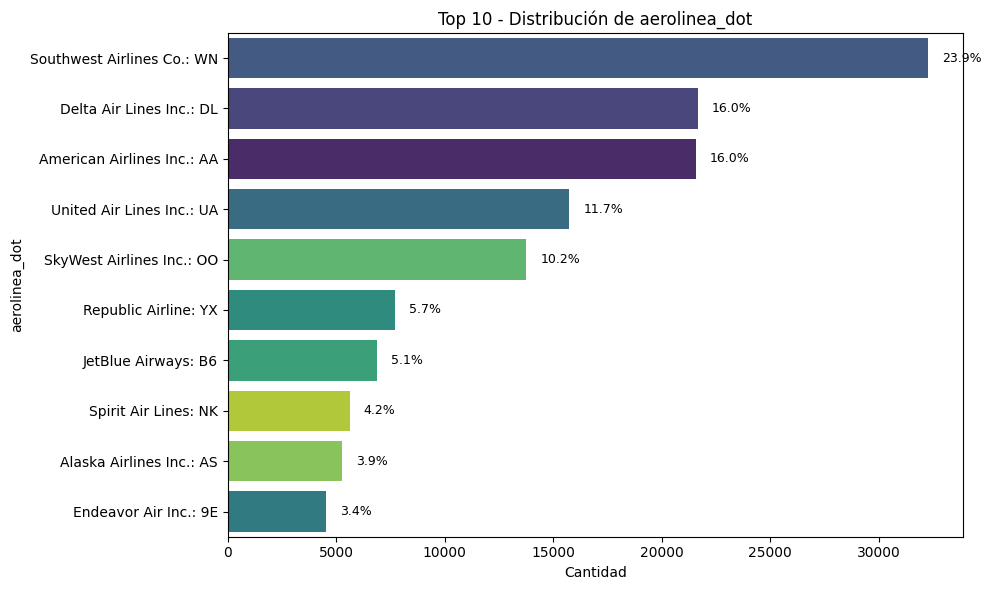

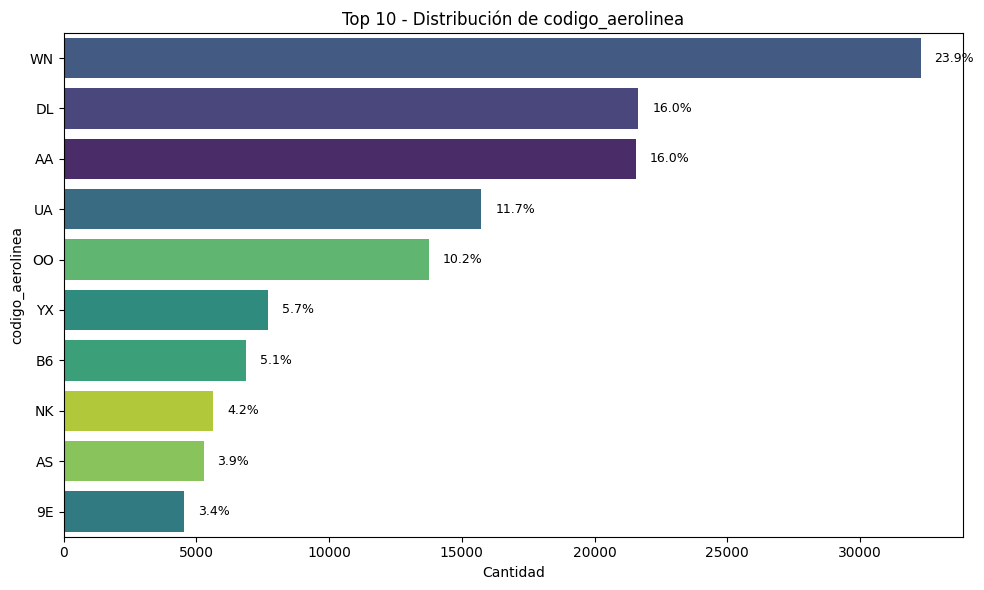

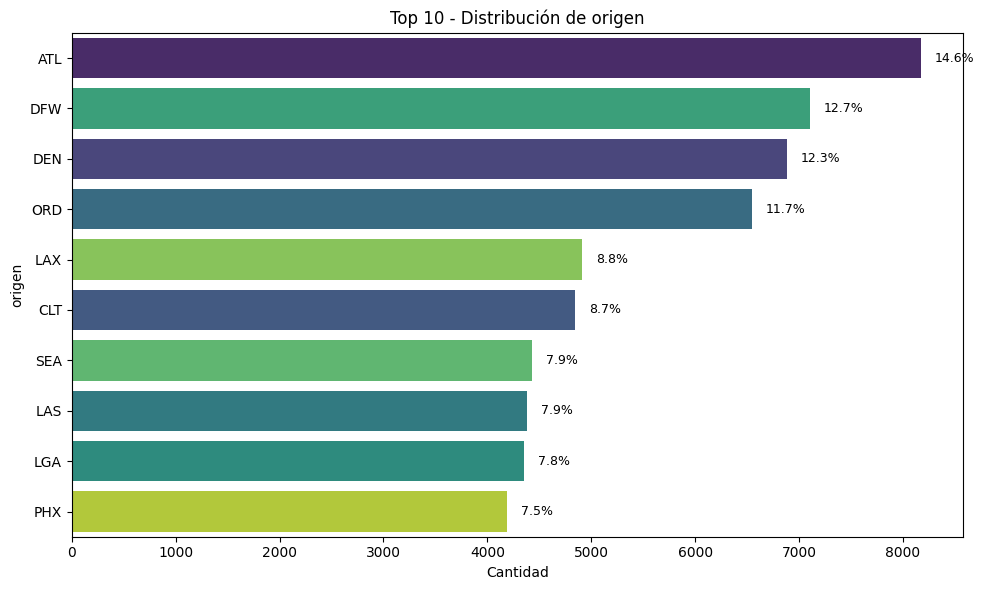

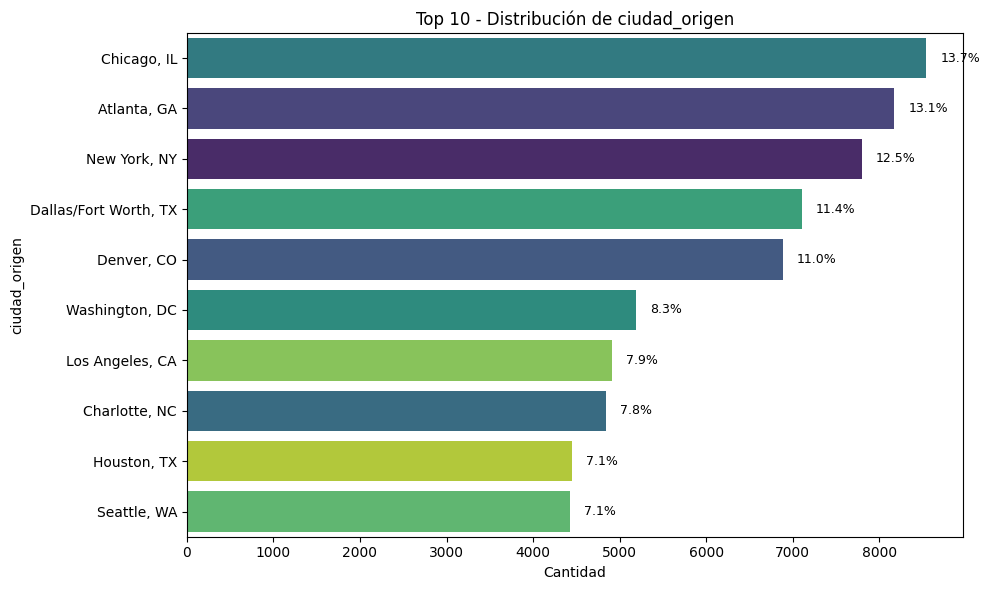

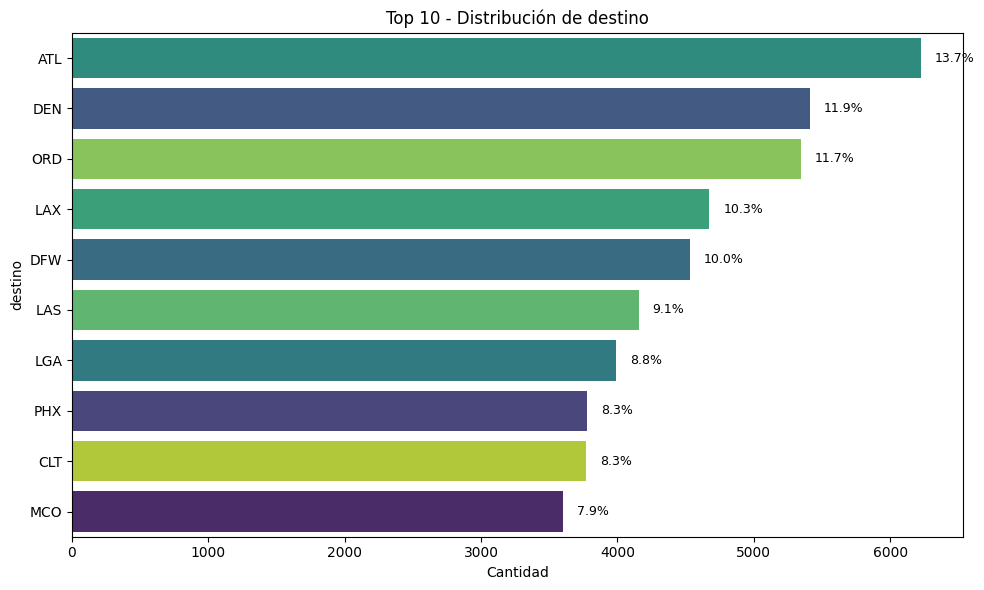

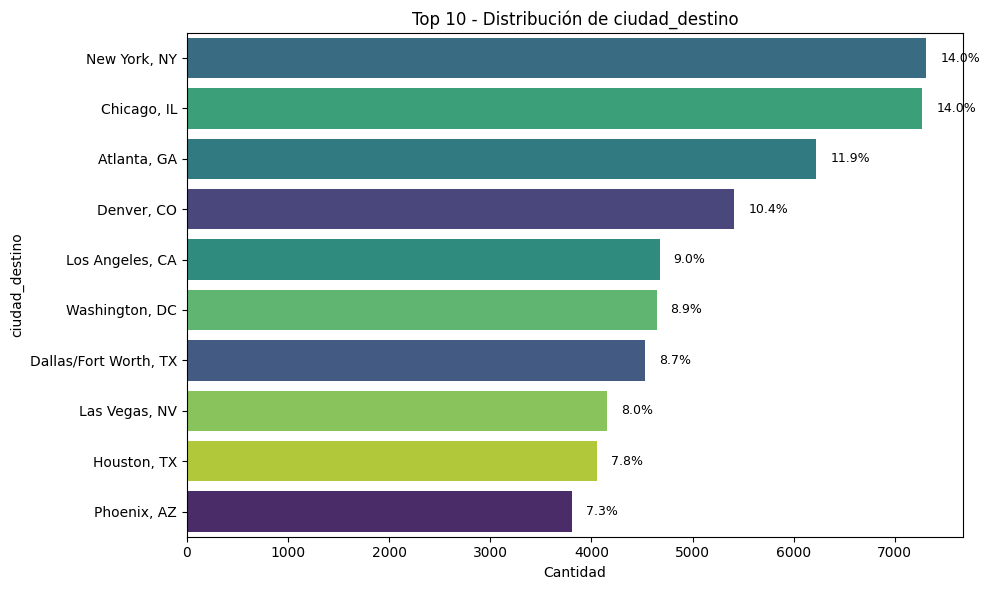

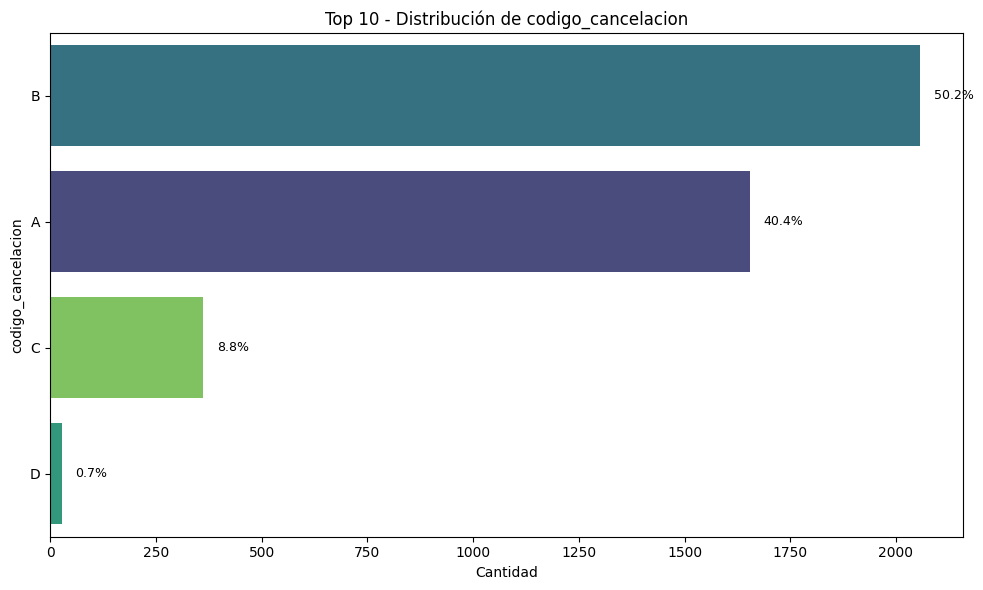

In [33]:
for col in categorical_columns:
    top10 = df_2022[col].value_counts().nlargest(10).index
    df_top10 = df_2022[df_2022[col].isin(top10)]

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_top10, y=col, hue=col, palette='viridis', legend=False, order=top10)
    plt.title(f'Top 10 - Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)

    total = len(df_top10)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y), ha='left', va='center', fontsize=9, color='black', xytext=(10, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

Condición climática

La mayoría de los vuelos se registraron bajo condiciones de cielo mayormente nublado o despejado, mientras que las condiciones de con viento y lluevia representan una proción minoritaria, lo que nos da a entender que el clima adverso no es lo más usual.

mostly_cloudy: 32.7%
fair: 18.1%
cloudy: 17.9%

Por otro lado, existe una fuerte concnetración en pocos aeropuertos como LAX (Los Ángeles) con un 25%, seguido por SFO (San Francisco) con un 14% y luego BOS (Boston) con un 10.4%. Lo cual nos puede indicar que la mayoría de los vuelos son más para el Oeste de EEUU.

Por último, podemos ver que las aerolíneas con mayor cantidad de vuelos son JetBlue con un 33.3% y Delta con un 26.6% representan en conjunto un 60% de los vuelos.